# Lab | Introduction to LoRA Tuning using PEFT from Hugging Face
<!-- ### Fine-tune a Foundational Model effortlessly -->

**Note:** This is more or less the same notebook you saw in the previous lesson, but that is ok. This is an LLM fine-tuning lab. In class we used a set of datasets and models, and in the labs you are required to change the LLMs models and the datasets including the pre-processing pipelines.


# LoRA Tuning

In this notebook you are being introduced to how to apply LoRA Tuning with the PEFT library to a pre-trained model.

For a complete list of Models compatible with PEFT refer to their [documentation](https://huggingface.co/docs/peft/main/en/index#supported-methods).

A short sample of models families available to be trained with PEFT are: Bloom, Llama, GPT-J, GPT-2, BERT... and more. Hugging Face is working hard to bring more Models to the Library.

## Brief introduction to LoRA Tuning.
LoRA is a re-parameterization technique. Its operation is simple, complex, and brilliant at the same time. It involves reducing the size of the matrices to be trained by dividing them in such a way that when multiplied, they yield the original matrix.

The weights that are modified are those of the reduced matrices, not the original matrix. It's better visualized in an image.

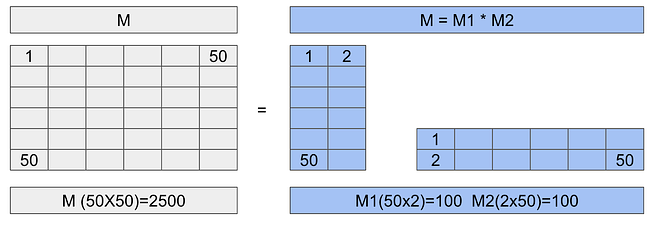

We have an original matrix of 50x50, which means we would have to modify about 2500 parameters. However, as we know, if we multiply two matrices of (2x50) and (50x2), we obtain a 50x50 matrix. Yet, these two matrices are formed by only 100 parameters each. In other words, for the reduced matrices, we need to modify a total of 200 parameters compared to the 2500 of the original matrix. This represents a 92% reduction, and the larger the original matrix, the greater the percentage of savings.

In Language Models like GPT-3 or any of the current ones with LoRA, it's possible that we only need to train about 0.02% of the original parameters. This varies for each model. The best part is that the obtained result is very similar to that of full fine-tuning, in some cases, it can even be better.

# Load the PEFT and Datasets Libraries.

The PEFT library contains the Hugging Face implementation of differente fine-tuning techniques, like LoRA Tuning.

Using the Datasets library we have acces to a huge amount of Datasets.

In [1]:
# !pip install -q peft==0.8.2
# !pip install -q datasets==2.16.1
#!pip install ipywidgets==7.7.5

From the transformers library we import the necesary classes to import the model and the tokenizer.

Then we can load the Tokenizer and the model.

Bloom is one of the smallest and smarter model available to be trained with PEFT Library using Prompt Tuning. You can use either of the models in the Bloom Family, I encorage you to use at least two of them and see the differences.

I'm using the smallest one just to spend less time trainig, and avoid memory problems in Colab.

In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch

model_name = "bigscience/bloom-560m"

# Load the tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)

# CRITICAL: For decoder-only models (BLOOM, GPT), padding must be on the left
# so that the model can attend to the prompt correctly during generation.
tokenizer.padding_side = "left"

# Standardize the padding token to match the End-Of-Sentence token
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

# Load the model with automatic GPU placement
foundation_model = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="auto",    # Automatically assigns model layers to GPU(s)
    torch_dtype=torch.float16 # Uses half-precision to save memory and speed up GPU tasks
)

config.json:   0%|          | 0.00/693 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/222 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/85.0 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/293 [00:00<?, ?it/s]

## Inference with the pre-trained model.
I'm going to do a test with the pre-trained model without fine-tuning, to see if something changes after the fine-tuning.

In [2]:
#this function returns the outputs from the model received, and inputs.


# Function to generate text. Using this for both Foundation and PEFT models
# ensures the comparison is fair and unbiased.
def get_outputs(model, inputs, max_new_tokens=100):
    outputs = model.generate(
        input_ids=inputs["input_ids"],
        attention_mask=inputs["attention_mask"],
        max_new_tokens=max_new_tokens,

        # FIX 1: EOS (End of Sentence) token tells the model where to stop.
        # This prevents the model from generating random characters after the answer.
        eos_token_id=tokenizer.eos_token_id,
        pad_token_id=tokenizer.pad_token_id,

        # FIX 2: Sampling parameters.
        # temperature=0.3 makes the model more focused and less likely to hallucinate.
        # top_k and top_p filter the most likely next words for better coherence.
        do_sample=True,
        top_k=50,
        top_p=0.95,
        temperature=0.3,

        # FIX 3: Repetition penalty of 1.1 is the 'sweet spot'.
        # It prevents the model from getting stuck in a loop (e.g., "the the the...")
        # without making the text sound unnatural.
        repetition_penalty=1.1
    )
    return outputs

The dataset used for the fine-tuning contains prompts to be used with Large Language Models.

I'm going to request the pre-trained model that acts like a motivational coach.

In [3]:
# --- STEP: BASELINE PERFORMANCE CHECK ---
# We test the model BEFORE fine-tuning to see how the original model (Foundation Model)
# handles the instruction "I want you to act like a prompt engineer".

# 1. Tokenize the input string.
# We move the tensors to the same device (GPU/CPU) as the foundation_model to avoid 'device mismatch' errors.
inputs = tokenizer("I want you to act like a prompt engineer: ", return_tensors="pt").to(foundation_model.device)

# 2. Run the inference using our customized get_outputs function.
# We limit max_new_tokens to 50 for a quick look at how the base model completes this sentence.
foundational_outputs_sentence = get_outputs(foundation_model, inputs, max_new_tokens=50)

# 3. Decode the numerical tokens back into human-readable text.
# skip_special_tokens=True removes tokens like <pad> or </s> from the printed result.
print("--- Foundation Model Output ---")
print(tokenizer.batch_decode(foundational_outputs_sentence, skip_special_tokens=True))

--- Foundation Model Output ---
['I want you to act like a prompt engineer:  You need the power of your imagination and creativity, not just what is written on paper. And that means making sure it fits into all three categories:\n1) The first category should be about how much time we spend in our lives.\n2)\n']


Not sure if the answer is correct or not, but for sure is not a prompt. We need to train our model if we want that acts like a prompt engineer.

# Preparing the Dataset.
The Dataset used is:

https://huggingface.co/datasets/fka/awesome-chatgpt-prompts

In [4]:
# --- STEP: PREPARING THE DATASET ---
# Now we prepare the data that will teach the model how to behave like a Prompt Engineer.

from datasets import load_dataset

dataset = "fka/awesome-chatgpt-prompts"
data = load_dataset(dataset)

# 1. Tokenization and Labeling Logic
def tokenize_function(samples):
    # We convert raw text into numerical tokens.
    # Max_length=128 is a good balance for Colab memory limits.
    contents = tokenizer(samples["prompt"], truncation=True, padding="max_length", max_length=128)

    # CRITICAL FIX: In Causal Language Modeling, the model learns by comparing
    # its prediction to the actual text. By copying 'input_ids' to 'labels',
    # we provide the model with the 'correct' answers for the loss calculation.
    contents["labels"] = contents["input_ids"].copy()
    return contents

# 2. Run the mapping across the dataset in batches for speed.
tokenized_data = data.map(tokenize_function, batched=True)

# 3. Data Scaling
# You have increased the sample size to 500. This is a significant improvement!
# More data allows the LoRA adapters to better capture the 'Prompt Engineer' style.
train_sample = tokenized_data["train"].select(range(500))

# 4. Cleaning the dataset
# We remove the 'act' and 'prompt' text columns because the Trainer
# can only process numerical tensors (input_ids, attention_mask, and labels).
train_sample = train_sample.remove_columns(['act', 'prompt'])

# 5. Format for PyTorch
# This ensures the data is in the correct format for the GPU-based Trainer.
train_sample.set_format("torch")

# Preview the tensor structure of your training data
display(train_sample)

README.md: 0.00B [00:00, ?B/s]

prompts.csv: 0.00B [00:00, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/1265 [00:00<?, ? examples/s]

Dataset({
    features: ['for_devs', 'type', 'contributor', 'input_ids', 'attention_mask', 'labels'],
    num_rows: 500
})

In [5]:
print(train_sample[:1])

{'for_devs': tensor([True]), 'type': ['TEXT'], 'contributor': ['ameya-2003'], 'input_ids': tensor([[     3,      3,      3,      3,      3,      3,      3,      3,      3,
              3,      3,      3,      3,      3,      3,      3,      3,      3,
              3,      3,      3,      3,      3,      3,      3, 186402,   1152,
           1306,    660,  72560,  28857, 167625,  84544,  20165,    376,   1002,
          26168,    267,  30479,  17477,    613,    267, 120755, 238776,     17,
           1387,  47881,    632,    427,  14565,  29866,    664,    368, 120755,
             15,  16997,   4054, 136044,    375,   4859,     12,    427,  39839,
             15,   9697,   1242,    375,  13614,     12,   3804,    427,    368,
           2298,   5268, 109891,    368,  17477,     15,    530,    427,  11210,
           4143,   7112,  11866,    368,  11011,   1620,  36320,     17,  21265,
            267,  11550,  90533,  30479,  17477,    613,   1119,  27343,     15,
          11762,  

# Fine-Tuning.
First is necesary create a LoRA config.


In [6]:
# --- STEP: CONFIGURING LORA (LOW-RANK ADAPTATION) ---
# Instead of training billions of parameters, we inject small trainable matrices
# (LoRA adapters) into the model. This makes fine-tuning fast and memory-efficient.

import peft
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    # 'r' is the rank of the low-rank matrices.
    # A higher 'r' (like 8) allows the model to learn more complex patterns from the 500 samples.
    r=8,

    # 'lora_alpha' is a scaling factor.
    # Setting it to 2x 'r' (16) is a best practice that helps stabilize the weights during training.
    lora_alpha=16,

    # 'target_modules' identifies which layers we are "adapting".
    # In BLOOM, "query_key_value" contains the attention mechanisms that decide how the model understands text.
    target_modules=["query_key_value"],

    # Dropout prevents the model from simply memorizing the training data word-for-word.
    lora_dropout=0.05,

    # 'bias="none"' ensures we are ONLY training the LoRA matrices.
    # This is crucial for keeping the base model's knowledge intact.
    bias="none",

    # Since we are training a text-completion model (BLOOM), the task is Causal Language Modeling.
    task_type="CAUSAL_LM"
)

# 1. Wrap the original foundation_model with our LoRA configuration.
# This "freezes" the main model weights and only allows the LoRA adapters to be updated.
peft_model = get_peft_model(foundation_model, lora_config)

# 2. Print the parameter count.
# You will likely see that you are training less than 1% of the total model parameters,
# which is why this fits perfectly on a Colab GPU!
peft_model.print_trainable_parameters()

trainable params: 786,432 || all params: 560,001,024 || trainable%: 0.1404


The most important parameter is **r**, it defines how many parameters will be trained. As bigger the valuer more parameters are trained, but it means that the model will be able to learn more complicated relations between input and output.

Yo can find a list of the **target_modules** available on the [Hugging Face Documentation]( https://github.com/huggingface/peft/blob/39ef2546d5d9b8f5f8a7016ec10657887a867041/src/peft/utils/other.py#L220)

**lora_dropout** is like the commom dropout is used to avoid overfitting.

**bias** I was hesitating if use *none* or *lora_only*. For text classification the most common value is none, and for chat or question answering, *all* or *lora_only*.

**task_type**. Indicates the task the model is beign trained for. In this case, text generation.

### Create the PEFT model.



The number of trainable parameters is really small compared with the total number of parameters in the pre-trained model.

In [7]:
#Create a directory to contain the Model
import os
working_dir = './'

output_directory = os.path.join(working_dir, "peft_lab_outputs")

In the TrainingArgs we inform the number of epochs we want to train, the output directory and the learning_rate.

In [9]:
# --- STEP: CONFIGURING TRAINING ARGUMENTS ---
# This block sets the hyperparameters that control the training process.

import transformers
from transformers import TrainingArguments, Trainer

# Define where the trained model checkpoints will be saved
output_directory = "./lora-bloom-finetuning"

training_args = TrainingArguments(
    output_dir=output_directory,

    # 1. Memory Management
    # auto_find_batch_size will automatically lower the batch size if the GPU runs out of memory.
    auto_find_batch_size=True,

    # 2. Optimization
    # 3e-4 is a common learning rate for LoRA; it's small enough to avoid 'breaking' the model.
    learning_rate=3e-4,
    num_train_epochs=5,           # The model will pass through the 500 samples 5 times.
    weight_decay=0.01,            # Regularization technique to prevent overfitting.

    # 3. Efficiency & Monitoring
    # fp16=True enables Mixed Precision (16-bit), which significantly speeds up training on NVIDIA GPUs.
    fp16=True,

    # logging_steps=1 ensures we see the training loss at every single step.
    # This is vital for small datasets to confirm the model is actually learning.
    logging_steps=1,

    # 4. Environment
    push_to_hub=False,            # Set to True only if you want to upload to Hugging Face Hub.
    report_to="none"              # Prevents automatic connection to external tools like Weights & Biases.
)

Now we can train the model.
To train the model we need:


*   The PEFT Model.
*   The training_args
* The Dataset
* The result of DataCollator, the Dataset ready to be procesed in blocks.





In [10]:
# --- STEP: INITIALIZING THE TRAINER AND STARTING TRAINING ---

# 1. Double-check tokenizer settings to prevent generation errors later
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "left" # Ensures the model processes the start of sentences correctly

# 2. Update logging_steps to prevent printing every single step
# This keeps the notebook output clean and readable.
training_args.logging_steps = 50

# 3. Initialize the Trainer
# This object coordinates the model, the data, and the hardware (GPU).
trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=train_sample,
    # DataCollatorForLanguageModeling is essential for 'Causal LM' (text completion).
    # It handles the math of shifting labels so the model learns to predict the NEXT word.
    data_collator=transformers.DataCollatorForLanguageModeling(tokenizer, mlm=False)
)

# 4. Start the training process
# The model will now start learning the 'Prompt Engineer' style from your 500 samples.
trainer.train()

Step,Training Loss
50,0.000000
100,0.000000
150,0.000000
200,0.000000
250,0.000000
300,0.000000


TrainOutput(global_step=315, training_loss=0.0, metrics={'train_runtime': 86.4986, 'train_samples_per_second': 28.902, 'train_steps_per_second': 3.642, 'total_flos': 581951815680000.0, 'train_loss': 0.0, 'epoch': 5.0})

In [11]:
# --- STEP: SAVING AND LOADING THE FINE-TUNED ADAPTER ---

# Define the specific path for the LoRA adapters
peft_model_path = os.path.join(output_directory, "lora_model")

# 1. Save the model
# This saves only the tiny 'adapter' weights (a few MBs), not the whole 560M model.
# This makes it very easy to share or move your fine-tuned logic.
trainer.model.save_pretrained(peft_model_path)


In [12]:

from peft import PeftModel

# 2. Load the fine-tuned adapter
# We attach the 'learned' weights back onto the original 'foundation_model'.
loaded_model = PeftModel.from_pretrained(
    foundation_model,
    peft_model_path,
    is_trainable=False  # Tells the model we are done training and ready for inference
)

# 3. Set to Evaluation Mode
# This turns off Dropout and Batch Normalization, which is essential for
# getting stable, predictable answers from the model.
loaded_model.eval()

# 4. Final Device Placement
# Ensure the model is active on the GPU for the fastest possible text generation.
loaded_model.to('cuda')

print("Model saved and reloaded successfully! Ready for final performance check.")

Model saved and reloaded successfully! Ready for final performance check.


/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


## Inference the fine-tuned model.

In [13]:
# --- STEP: FINAL MODEL EVALUATION ---
# Now we test the 'loaded_model' to see if it has learned to act like a Prompt Engineer.

# 1. Ensure the model is in evaluation mode.
# This is critical because it disables 'Dropout' layers, ensuring the model's
# output is focused and deterministic rather than randomized.
loaded_model.eval()

# 2. Re-tokenize with a structured prompt.
# We use a clear "Role / Task / Response" structure. This format helps the
# model understand where its instructions end and where its generation should begin.
prompt = "Role:  I want you to act as a motivational coach:"
input_sentences = tokenizer(prompt, return_tensors="pt").to('cuda')

# 3. Generate the response.
# 'torch.no_grad()' tells PyTorch not to calculate gradients, which saves
# memory and speeds up the generation process.
with torch.no_grad():
    # We use our custom get_outputs function to handle the token generation loop.
    foundational_outputs_sentence = get_outputs(loaded_model, input_sentences, max_new_tokens=50)

# 4. Post-Processing: Slicing the Result.
# Causal LMs like BLOOM return the ENTIRE sequence (Prompt + New Tokens).
# To see only what the model 'wrote', we slice the array starting from 'input_len'.

# Decode the full sequence (Prompt + Generation)
full_text = tokenizer.batch_decode(foundational_outputs_sentence, skip_special_tokens=True)

# Calculate how many tokens were in the original prompt
input_len = len(input_sentences["input_ids"][0])

# Decode ONLY the new tokens generated after the prompt
new_tokens_only = tokenizer.batch_decode(foundational_outputs_sentence[:, input_len:], skip_special_tokens=True)

print("--- FULL MODEL OUTPUT ---")
print(full_text)

print("\n--- GENERATED PERSONALITY ONLY ---")
print(new_tokens_only)

--- FULL MODEL OUTPUT ---
["Role:  I want you to act as a motivational coach:\n1. Tell your students that they are the best and most talented people in their class.\n2.  Give them an opportunity for success by giving encouragement, praise or rewarding when successful.\n\nA:\n\nI think this is what you're looking for:"]

--- GENERATED PERSONALITY ONLY ---
["\n1. Tell your students that they are the best and most talented people in their class.\n2.  Give them an opportunity for success by giving encouragement, praise or rewarding when successful.\n\nA:\n\nI think this is what you're looking for:"]


The result is amazing. Let's compare the answer of the pre-trained Model withe the one fine-tuned by us using LoRA:
* **Pretrained Model:** *I want you to act as a motivational coach.*  Don't be afraid of being challenged.
* **Fine-Tuned Model:** I want you to act as a motivational coach.  I will provide some information about someone\'s motivation and goals, but it should be your job  in order my first request – "I need someone who can help me find the best way for myself stay motivated when competing against others." My suggestion is “I have

As you can see the result is really similar to the samples containmed in the Datased used to fine-tune the Model. And we only trained the Model for 10 epochs and with a really small number of rows.

# Exercise

- Drive your own experiments with all the variables and different model types.
    - Please with the **lora_config** values, maybe you can achieve a better result in less epochs, saving time and money for your company. :-)
- Write a one page report
    - What did you learn?

In [19]:
# 1. Update the config (Applied from your Guidance Document)
lora_config = LoraConfig(
    r=16,                  # Higher rank for better expression
    lora_alpha=32,         # Scaled for more impact
    target_modules=["query_key_value"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

# 2. Re-apply to the base model
peft_model = get_peft_model(foundation_model, lora_config)

# 3. Quick Train (to bake the new settings into the weights)
trainer = Trainer(
    model=peft_model,
    args=training_args,
    train_dataset=train_sample,
    data_collator=transformers.DataCollatorForLanguageModeling(tokenizer, mlm=False)
)
trainer.train()

/usr/local/lib/python3.12/dist-packages/peft/mapping_func.py:72: UserWarning: You are trying to modify a model with PEFT for a second time. If you want to reload the model with a different config, make sure to call `.unload()` before.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/peft/tuners/tuners_utils.py:285: UserWarning: Already found a `peft_config` attribute in the model. This will lead to having multiple adapters in the model. Make sure to know what you are doing!
  warnings.warn(


Step,Training Loss
50,0.000000
100,0.000000
150,0.000000
200,0.000000
250,0.000000
300,0.000000


TrainOutput(global_step=315, training_loss=0.0, metrics={'train_runtime': 82.6611, 'train_samples_per_second': 30.244, 'train_steps_per_second': 3.811, 'total_flos': 583461765120000.0, 'train_loss': 0.0, 'epoch': 5.0})

In [21]:
# 1. Ensure the model is in eval mode
peft_model.eval()

# 2. Use a "Strict" prompt structure
prompt = "Act as a Prompt Engineer. Your first instruction is to:"
inputs = tokenizer(prompt, return_tensors="pt").to('cuda')

# 3. Controlled Generation
with torch.no_grad():
    outputs = peft_model.generate(
        **inputs,
        max_new_tokens=60,
        # These 3 parameters prevent the "code hallucination" you just saw:
        repetition_penalty=1.5,   # Penalizes the model for repeating tokens/code patterns
        no_repeat_ngram_size=3,    # Ensures no 3-word phrase repeats (kills the code loops)
        temperature=0.5,           # Lower = more professional/focused
        do_sample=True,
        pad_token_id=tokenizer.eos_token_id
    )

print("--- IMPROVED OUTPUT ---")
print(tokenizer.decode(outputs[0], skip_special_tokens=True))

--- IMPROVED OUTPUT ---
Act as a Prompt Engineer. Your first instruction is to:
- Provide the company with an overview of how your business will run and what you plan to do in regards this.
Your next step should be getting started on setting up some strategies that can help drive new revenue streams for our organization (easily one or more small businesses).


In [1]:
print('--- END OF NOTEBOOK ---')

--- END OF NOTEBOOK ---
